In [ ]:
import numpy as np
from random import randint
from sklearn.utils import shuffle
from sklearn.preprocessing import MinMaxScaler

In [ ]:
train_samples = []
train_labels = []



*   total 2100 participants. half were under 65 years old, half were 65 years or older
*   95% of patients or older experienced side effects
*   95% of patients under 65 experienced no side effects





In [ ]:
for i in range(50):
  # The ~50 of younger individuals who did experince side effects
  random_younger = randint(13, 64)
  train_samples.append(random_younger)
  train_labels.append(1)


  # ~5% of older individuals who did not experience side effects
  random_older = randint(65, 100)
  train_samples.append(random_older)
  train_labels.append(0)


for i in range(1000):
  # The ~95 of younger individuals who did not experince side effects
  random_younger = randint(13, 64)
  train_samples.append(random_younger)
  train_labels.append(0)


  # ~95% of older individuals who did experience side effects
  random_older = randint(65, 100)
  train_samples.append(random_older)
  train_labels.append(1)



In [ ]:
train_labels = np.array(train_labels)
train_samples = np.array(train_samples)
train_labels, train_samples = shuffle(train_labels, train_samples)

print(train_labels)

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train_samples = scaler.fit_transform(train_samples.reshape(-1, 1))

In [ ]:
for i in range(10):
  x = randint(0, 100)
  print(scaled_train_samples[x], train_labels[x])

[0.51724138] 0
[0.31034483] 0
[0.87356322] 1
[0.43678161] 0
[0.22988506] 0
[0.42528736] 0
[0.40229885] 0
[0.65517241] 1
[0.52873563] 0
[0.04597701] 0


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Activation, Dense
from keras.optimizers import Adam
from keras.metrics import categorical_crossentropy


In [ ]:
# to make tensorflow identify the GPU
physical_devices = tf.config.experimental.list_physical_devices('GPU')
print('Num GPUs Available: ', len(physical_devices))
# tf.config.experimental.set_memory_growth(physical_devices[0], True)

Num GPUs Available:  0


In [ ]:
model = Sequential([
    Dense(units=10, input_shape=(1,), activation='relu'),
    Dense(units=32, activation='relu'),
    Dense(units=2, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 438 (1.71 KB)

 Trainable params: 438 (1.71 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(x=scaled_train_samples, y=train_labels, validation_split=0.1, batch_size=10, epochs=30, shuffle=True, verbose=2)

Epoch 1/30
189/189 - 2s - 11ms/step - accuracy: 0.9085 - loss: 0.3393 - val_accuracy: 0.9571 - val_loss: 0.2685
Epoch 2/30
189/189 - 1s - 3ms/step - accuracy: 0.9233 - loss: 0.2594 - val_accuracy: 0.9000 - val_loss: 0.2831
Epoch 3/30
189/189 - 1s - 3ms/step - accuracy: 0.9190 - loss: 0.2678 - val_accuracy: 0.9286 - val_loss: 0.2540
Epoch 4/30
189/189 - 0s - 2ms/step - accuracy: 0.9291 - loss: 0.2491 - val_accuracy: 0.9286 - val_loss: 0.2586
Epoch 5/30
189/189 - 0s - 2ms/step - accuracy: 0.9328 - loss: 0.2383 - val_accuracy: 0.9571 - val_loss: 0.2372
Epoch 6/30
189/189 - 0s - 2ms/step - accuracy: 0.9413 - loss: 0.2294 - val_accuracy: 0.9571 - val_loss: 0.2314
Epoch 7/30
189/189 - 0s - 2ms/step - accuracy: 0.9423 - loss: 0.2299 - val_accuracy: 0.9333 - val_loss: 0.2338
Epoch 8/30
189/189 - 0s - 2ms/step - accuracy: 0.9418 - loss: 0.2244 - val_accuracy: 0.9524 - val_loss: 0.2240
Epoch 9/30
189/189 - 0s - 2ms/step - accuracy: 0.9418 - loss: 0.2205 - val_accuracy: 0.9286 - val_loss: 0.2257


In [ ]:
test_samples = []
test_labels = []


for i in range(10):
  # The ~50 of younger individuals who did experince side effects
  random_younger = randint(13, 64)
  test_samples.append(random_younger)
  test_labels.append(1)


  # ~5% of older individuals who did not experience side effects
  random_older = randint(65, 100)
  test_samples.append(random_older)
  test_labels.append(0)


for i in range(200):
  # The ~95 of younger individuals who did not experince side effects
  random_younger = randint(13, 64)
  test_samples.append(random_younger)
  test_labels.append(0)


  # ~95% of older individuals who did experience side effects
  random_older = randint(65, 100)
  test_samples.append(random_older)
  test_labels.append(1)

In [ ]:
test_labels = np.array(test_labels)
test_samples = np.array(test_samples)
test_labels, test_samples = shuffle(test_labels, test_samples)

In [ ]:
scaled_test_samples = scaler.fit_transform(test_samples.reshape(-1, 1))

# **Predict**

In [ ]:
predictions = model.predict(x=scaled_test_samples, batch_size=10, verbose=0)

In [ ]:
for i in predictions:
  print(i)

[0.03618773 0.9638123 ]
[0.03783138 0.9621685 ]
[0.15859003 0.8414099 ]
[0.04100228 0.9589976 ]
[0.9624461  0.03755381]
[0.9595884  0.04041166]
[0.04027635 0.9597235 ]
[0.9624461  0.03755381]
[0.96065295 0.03934701]
[0.03956274 0.9604373 ]
[0.03783138 0.9621685 ]
[0.9624461  0.03755381]
[0.9624461  0.03755381]
[0.9569768  0.04302321]
[0.9624461  0.03755381]
[0.04136993 0.95863   ]
[0.9624461  0.03755381]
[0.96087134 0.03912862]
[0.03516752 0.96483254]
[0.96219957 0.03780038]
[0.15859003 0.8414099 ]
[0.03716357 0.96283627]
[0.95043427 0.0495657 ]
[0.03581812 0.96418184]
[0.9616908  0.03830933]
[0.03716357 0.96283627]
[0.03586796 0.964132  ]
[0.03750088 0.96249914]
[0.9624462  0.03755381]
[0.9624462  0.03755381]
[0.9624461  0.03755381]
[0.9616908  0.03830933]
[0.04063777 0.95936227]
[0.03783138 0.9621685 ]
[0.9624461  0.03755381]
[0.03855544 0.9614447 ]
[0.03581812 0.96418184]
[0.04174073 0.95825917]
[0.9624462  0.03755381]
[0.03817173 0.96182823]
[0.03855544 0.9614447 ]
[0.15859003 0.84

In [ ]:
np.round(predictions)

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.

In [ ]:
rounded_predictions = np.argmax(predictions, axis=-1)
rounded_predictions

array([1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,

In [ ]:
sum = 0
for i in range(len(rounded_predictions)):
  sum += abs(rounded_predictions[i] - test_labels[i])

print(sum)

20


In [ ]:
%matplotlib inline
from sklearn.metrics import confusion_matrix
import itertools
import matplotlib.pyplot as plt

In [ ]:
print(test_labels)
cm = confusion_matrix(y_true=test_labels, y_pred=rounded_predictions)

[1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 1 0 0 0 0 1 1 0 1 1
 1 0 1 1 1 0 1 0 0 0 1 1 0 0 0 0 1 0 1 1 1 0 1 1 0 0 0 0 1 1 1 0 0 0 0 1 1
 0 1 1 1 0 1 1 1 0 1 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 1 1 1 0 1 0 1 1 1 0 1 0
 0 0 0 0 0 1 1 0 1 1 1 1 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 0 1 1 0 1 0 1 1 1 1
 0 0 0 0 1 0 0 1 0 0 1 1 0 1 1 0 0 0 1 1 1 1 0 1 1 1 0 1 0 1 0 0 1 1 0 1 0
 1 1 0 0 1 0 0 0 1 1 1 0 1 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 1 0 1 0 1
 1 1 1 1 1 1 1 1 1 1 0 0 0 1 0 1 1 0 1 1 0 1 1 0 0 1 1 0 1 0 1 0 1 1 1 1 1
 1 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 1 0
 1 0 1 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1 1 1 0 1 0 1 0 0 1 1 0 0 1 1 1 1 0 1
 1 1 1 1 1 0 0 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 1 1 1 0 1 1 1 0 0 1 1 1 1 0 0
 1 0 0 0 0 0 0 1 0 0 1 0 1 1 1 0 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 1 1 1 0 1 1
 0 0 1 0 1 1 0 1 0 0 0 1 0]


In [ ]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
  plt.imshow(cm, interpolation='nearest', cmap=cmap)


  if normalize:
    cm=cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print('Normalized confusion matrix')
  else:
    print('Confusion matrix, without normalization')

  print(cm)

  thresh = cm.max() / 2
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")





Confusion matrix, without normalization
[[200  10]
 [ 10 200]]


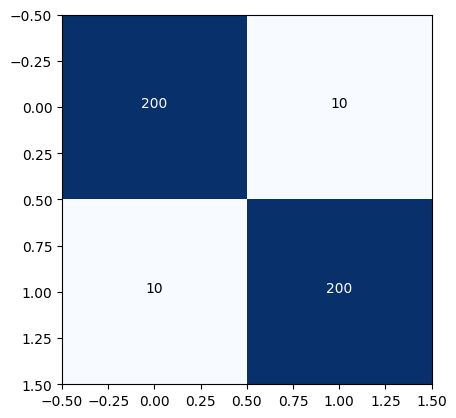

In [ ]:
cm_plot_lables = ['no_side_effects', 'had_side_effects']
plot_confusion_matrix(cm=cm, classes=cm_plot_lables, title='Confusion Matrix')

## Save and load Model


In [ ]:
import os.path
if os.path.isfile('models/medical_trial_model.h5') is False:
  model.save('models/medical_trial_model.h5')

In [ ]:
from tensorflow.keras.models import load_model
new_model = load_model('models/medical_trial_model.h5')

In [ ]:
new_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 440 (1.72 KB)

 Trainable params: 438 (1.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
new_model.get_weights()

[array([[ 1.0977658 ,  0.78474206, -1.2150987 , -0.02824032, -0.3724005 ,
          1.3463523 ,  0.6338587 , -0.7306801 , -0.42347676, -0.09328145]],
       dtype=float32),
 array([-0.6222189 , -0.39246893,  0.15172592,  0.        ,  0.        ,
        -0.7592791 , -0.4888462 ,  0.        ,  0.        ,  0.        ],
       dtype=float32),
 array([[-2.40088964e+00,  3.59190367e-02, -2.30088949e+00,
         -1.86174735e-01, -4.38046962e-01, -3.76278222e-01,
          1.15455079e+00, -3.72301549e-01, -2.24320102e+00,
         -1.86447275e+00,  1.81959242e-01,  6.62294030e-02,
         -1.63163781e-01, -1.75969496e-01, -2.80654222e-01,
         -2.15689802e+00, -2.00830087e-01, -8.55774641e-01,
         -6.21146619e-01,  2.55173236e-01, -2.56060120e-02,
         -2.79933214e-01,  1.75293118e-01, -2.16106653e-01,
          9.55934376e-02,  1.61966175e-01, -2.35289788e+00,
         -2.92107731e-01, -3.60515893e-01, -2.06471753e+00,
         -9.31182206e-02, -2.21282387e+00],
        [-1.2

In [ ]:
new_model.optimizer

## model.to_json()

if only need to save the architecture of a model, not its weights or its training configuration

In [ ]:
json_string = model.to_json()

In [ ]:
json_string

'{"module": "keras", "class_name": "Sequential", "config": {"name": "sequential", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_shape": [null, 1], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_layer"}, "registered_name": null}, {"module": "keras.layers", "class_name": "Dense", "config": {"name": "dense", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "units": 10, "activation": "relu", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "bias_initializer": {"module": "keras.initializers", "class_name": "Zeros", "config": {}, "registered_name": null}, "kernel_regularizer": null, "bias_regularizer": null, "ker

In [ ]:
# model reconstrunction from JSON.
from tensorflow.keras.models import model_from_json
model_architecture = model_from_json(json_string)

In [ ]:
model_architecture.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 878 (3.43 KB)

 Trainable params: 438 (1.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 440 (1.72 KB)

In [ ]:
model_architecture.get_weights()

[array([[ 0.08234525, -0.54070544, -0.00653428,  0.28180712, -0.12215567,
          0.47889704, -0.0523138 ,  0.6715674 , -0.16807657, -0.73645425]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.36267343, -0.3631604 ,  0.36631837,  0.23674664, -0.10330424,
         -0.24701324,  0.05770326, -0.31420502,  0.00470942, -0.2040325 ,
         -0.07350436,  0.1825665 ,  0.1167722 ,  0.0354602 ,  0.3482891 ,
         -0.02148104, -0.01573467,  0.2717565 ,  0.02166748,  0.24836758,
          0.32679763,  0.05204493, -0.0817976 , -0.19286424, -0.24200012,
          0.33987942, -0.29271957,  0.13403067,  0.17513958,  0.15638843,
          0.08156285,  0.09344786],
        [ 0.23766914, -0.07845539, -0.23872484,  0.0095962 ,  0.24938163,
         -0.22852126,  0.37111405, -0.35828543,  0.17205867, -0.09738925,
          0.3661513 ,  0.02535549, -0.03800213, -0.37793761, -0.10649705,
          0.32380053,  0.13270554, -0.27109948,  0.00551587,

# model.save_weights()

In [ ]:
import os.path
if os.path.isfile('models/my_model.weights.h5') is False:
  model.save_weights('models/my_model.weights.h5')

In [ ]:
model2 = Sequential([
    Dense(units=10, input_shape=(1, ), activation='relu'),
    Dense(units=32, activation='relu'),
    Dense(units=2, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model2.load_weights('models/my_model.weights.h5')

In [ ]:
model2.get_weights()

[array([[ 1.0977658 ,  0.78474206, -1.2150987 , -0.02824032, -0.3724005 ,
          1.3463523 ,  0.6338587 , -0.7306801 , -0.42347676, -0.09328145]],
       dtype=float32),
 array([-0.6222189 , -0.39246893,  0.15172592,  0.        ,  0.        ,
        -0.7592791 , -0.4888462 ,  0.        ,  0.        ,  0.        ],
       dtype=float32),
 array([[-2.40088964e+00,  3.59190367e-02, -2.30088949e+00,
         -1.86174735e-01, -4.38046962e-01, -3.76278222e-01,
          1.15455079e+00, -3.72301549e-01, -2.24320102e+00,
         -1.86447275e+00,  1.81959242e-01,  6.62294030e-02,
         -1.63163781e-01, -1.75969496e-01, -2.80654222e-01,
         -2.15689802e+00, -2.00830087e-01, -8.55774641e-01,
         -6.21146619e-01,  2.55173236e-01, -2.56060120e-02,
         -2.79933214e-01,  1.75293118e-01, -2.16106653e-01,
          9.55934376e-02,  1.61966175e-01, -2.35289788e+00,
         -2.92107731e-01, -3.60515893e-01, -2.06471753e+00,
         -9.31182206e-02, -2.21282387e+00],
        [-1.2